# Phase 1: Exploratory Data Analysis (EDA) & Data Cleaning

## Step 1: Project Setup & Data Ingestion
**Source (PDF Section: DATASET):** "Filter the conversations and treat each tweet as a support ticket. The dataset is noisy, unbalanced, and contains real language."

In this step, we initialize our environment with the necessary libraries for data manipulation, visualization, and serialization. We are loading the dataset from the local `data/` folder. 

**Strategy:** To maintain high development speed, we are loading an initial sample of 750,000 rows. Once the entire pipeline (Cleaning, ML, RAG, and UI) is verified, we can simply remove the `nrows` constraint to process the full 3M+ dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Setting the visual style for graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths relative to the notebooks/ directory
DATA_PATH = "../data/twcs/twcs.csv"
GRAPHS_PATH = "../graphs/"
PROCESSED_DATA_PATH = "../data/"

# Ensure the graphs folder exists
os.makedirs(GRAPHS_PATH, exist_ok=True)

print("Libraries imported and environment configured.")

# Load the raw data
# Using low_memory=False because the file is large and has mixed types in some columns
print(f"Loading data from {DATA_PATH}...")
df_raw = pd.read_csv(DATA_PATH, nrows=750000, low_memory=False)

print(f"Successfully loaded {len(df_raw)} rows.")
df_raw.head()

Libraries imported and environment configured.
Loading data from ../data/twcs/twcs.csv...
Successfully loaded 750000 rows.


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


## Step 2: Filtering for Target Brands
**Source (PDF Section: DATASET):** "Filter the conversations..."

The dataset contains millions of interactions across hundreds of brands. To make our Decision Intelligence Assistant focused and effective, we need to filter for specific high-volume brands. This ensures our ML model learns specific company "vibes" and our RAG system has a dense knowledge base for retrieval.

In [5]:
# Identify the most active brands (author_id)
# Support accounts usually have the word 'Support' or 'Help' in their handle
top_authors = df_raw['author_id'].value_counts().head(20)
print("Top 20 most active accounts in the sample:")
print(top_authors)

# Let's filter for a few major brands to keep the context consistent
# You can adjust this list based on the output above
target_brands = ['AmazonHelp', 'AppleSupport', 'Uber_Support', 'Delta', 'SpotifyCares']

# Filter for tweets where either the author is the brand, 
# OR the tweet is directed at the brand (text contains handle)
df_filtered = df_raw[df_raw['author_id'].isin(target_brands)].copy()

print(f"Rows after filtering for {target_brands}: {len(df_filtered)}")

Top 20 most active accounts in the sample:
author_id
AmazonHelp         59254
AppleSupport       23462
Uber_Support       15526
Delta              11147
SpotifyCares       10153
AmericanAir         9817
British_Airways     7998
comcastcares        7823
XboxSupport         7519
VirginTrains        7265
TMobileHelp         7254
SouthwestAir        6993
Tesco               6895
hulu_support        6559
AskPlayStation      6187
Safaricom_Care      5379
VerizonSupport      5162
ChipotleTweets      5045
sprintcare          4925
idea_cares          4892
Name: count, dtype: int64
Rows after filtering for ['AmazonHelp', 'AppleSupport', 'Uber_Support', 'Delta', 'SpotifyCares']: 119542


## Step 3: Initial EDA (Before Cleaning)
**Source (PDF Section: DATASET):** "The dataset is noisy, unbalanced... exactly what you will face in production."

Before we apply any cleaning transformations, we need to document the initial state of our filtered data. This allows us to compare "Before" and "After" once we've removed noise like URLs and handles. We will focus on:
1. **Brand Distribution:** Visualizing the imbalance between our target brands.
2. **Tweet Lengths:** Understanding the raw character counts to help define "priority" later (e.g., are longer tweets more urgent?).

/tmp/ipykernel_208068/54810381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x='author_id', order=target_brands, palette='viridis')


Saved brand distribution to ../graphs/brand_distribution_before.png
Saved tweet lengths to ../graphs/tweet_length_before.png

--- Raw Data Statistics ---
                count        mean        std
author_id                                   
AmazonHelp    59254.0  123.868313  47.036553
AppleSupport  23462.0  135.257139  47.248832
Delta         11147.0   99.319010  47.227908
SpotifyCares  10153.0  130.040678  37.465466
Uber_Support  15526.0  109.416463  37.177687


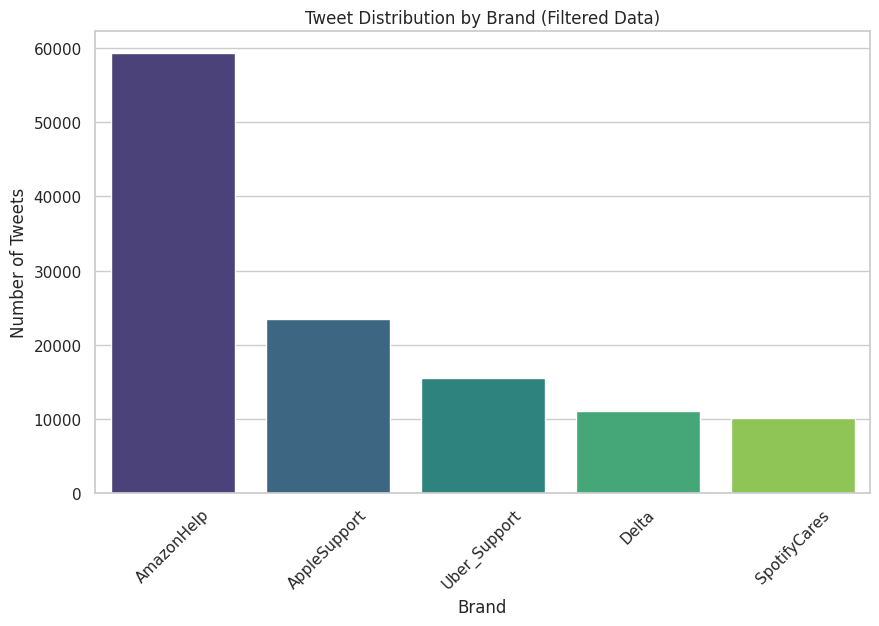

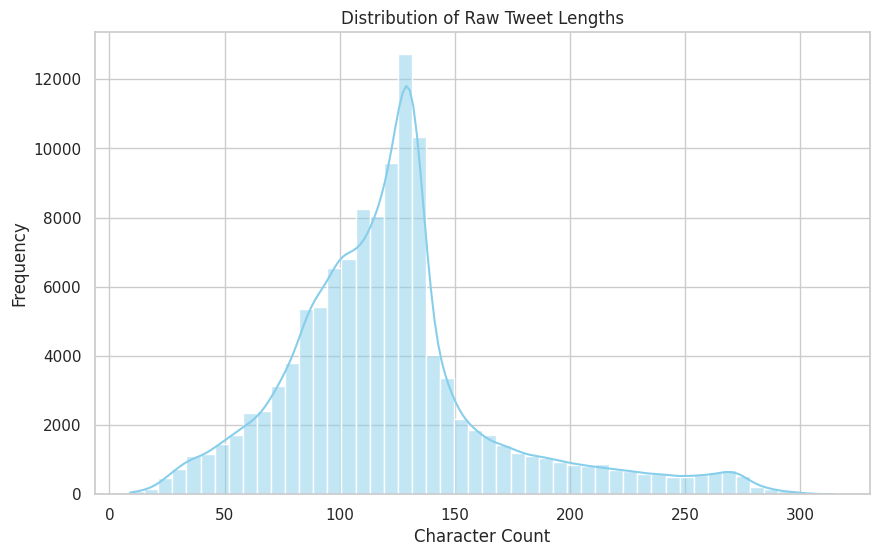

In [6]:
# 1. Brand Distribution Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='author_id', order=target_brands, palette='viridis')
plt.title('Tweet Distribution by Brand (Filtered Data)')
plt.xlabel('Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)

# Save the graph
plt.savefig(f"{GRAPHS_PATH}brand_distribution_before.png", bbox_inches='tight')
print(f"Saved brand distribution to {GRAPHS_PATH}brand_distribution_before.png")

# 2. Tweet Length Distribution
# We calculate length before cleaning to see the "noisy" state
df_filtered['text_length'] = df_filtered['text'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Raw Tweet Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

# Save the graph
plt.savefig(f"{GRAPHS_PATH}tweet_length_before.png", bbox_inches='tight')
print(f"Saved tweet lengths to {GRAPHS_PATH}tweet_length_before.png")

# Display basic stats for the report
print("\n--- Raw Data Statistics ---")
print(df_filtered.groupby('author_id')['text_length'].describe()[['count', 'mean', 'std']])

## Step 4: Text Cleaning Pipeline
**Source (PDF Section: DATASET):** "The dataset is noisy... contains real language."

Raw tweets are full of noise that can confuse an ML model or clutter a RAG retrieval. Our goal here is to strip away the "Twitter-ness" while keeping the "Sentiment." 

**Cleaning Strategy:**
1. **Lowercasing:** Standardizes "URGENT" and "urgent."
2. **Remove Handles (@user):** These don't help predict priority; they just identify the recipient.
3. **Remove URLs:** Most links in support are generic (e.g., bit.ly links to help docs).
4. **Remove Special Characters:** Strip out emojis and punctuation that don't add semantic value.
5. **Whitespace Normalization:** Ensure no double spaces or weird tabs remain.

In [7]:
import re

def clean_text(text):
    """
    Applies a series of regex patterns to clean a single tweet.
    """
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Remove Twitter handles (@user)
    text = re.sub(r'@\w+', '', text)
    
    # 4. Remove special characters and numbers (optional, keeping basic punctuation for now)
    # We keep a-z and basic spaces. 
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function
print("Cleaning text data... this may take a moment.")
df_filtered['clean_text'] = df_filtered['text'].apply(clean_text)

# Remove any rows that became empty after cleaning (e.g., a tweet that was just a URL)
df_filtered = df_filtered[df_filtered['clean_text'] != '']

print(f"Cleaning complete. Remaining rows: {len(df_filtered)}")

# Display a "Before and After" sample to verify the logic
print("\n--- Cleaning Verification ---")
sample_indices = df_filtered.sample(5).index
for idx in sample_indices:
    print(f"RAW: {df_filtered.loc[idx, 'text']}")
    print(f"CLEAN: {df_filtered.loc[idx, 'clean_text']}")
    print("-" * 30)

Cleaning text data... this may take a moment.
Cleaning complete. Remaining rows: 119361

--- Cleaning Verification ---
RAW: @300477 I request you to wait as our team is actively working on this and will get back soon. [2/2] ^SK
CLEAN: i request you to wait as our team is actively working on this and will get back soon sk
------------------------------
RAW: @169224 Sorry for the trouble. Kindly revert to this email and we'll check this for you. ^HN
CLEAN: sorry for the trouble kindly revert to this email and well check this for you hn
------------------------------
RAW: @315357 I'm sorry about that! You can manage and cancel your Prime membership by visiting us here: https://t.co/0yhqz9RHfj ^TK
CLEAN: im sorry about that you can manage and cancel your prime membership by visiting us here tk
------------------------------
RAW: @123495 We offer support via Twitter in English. Contact us for help in your preferred language here: https://t.co/IBIY3vMgPj
CLEAN: we offer support via twitter i

## Step 5: Heuristic Priority Labeling
**Source (PDF Section: DATASET & Rules):** "Label the data... define 'Priority' based on the dataset (e.g., keywords)." and "NO DISHONEST ACCURACY: If your ML model scores 95% accuracy, ask yourself 'is it learning urgency, or is it learning my labeling regex?'"

Since the raw dataset does not provide a 'Priority' label, we must create one using a keyword-based heuristic. We are defining **High Priority (1)** as tweets containing words related to financial loss, technical failure, or extreme frustration. **Low Priority (0)** includes general inquiries, "thank you" messages, and routine support.

**Heuristic Logic:**
We will use a predefined list of "Urgency Keywords." If a tweet contains any of these, it is flagged as High Priority. We acknowledge the risk of "learning the regex" and will use this as a baseline for our Decision Intelligence comparison.

--- Priority Label Distribution ---
Low Priority (0):  87183 (73.04%)
High Priority (1): 32178 (26.96%)

Saved distribution graph to ../graphs/priority_distribution.png

--- High Priority Samples ---
                                               clean_text
521403  we offer support via twitter in english contac...
558731  were here to help your situation is currently ...
273936  were here to help send us your email address a...
142298  here to help send us a note here and our team ...
652047  we want to check into these battery issues you...


/tmp/ipykernel_208068/1273119697.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x='priority', palette='magma')


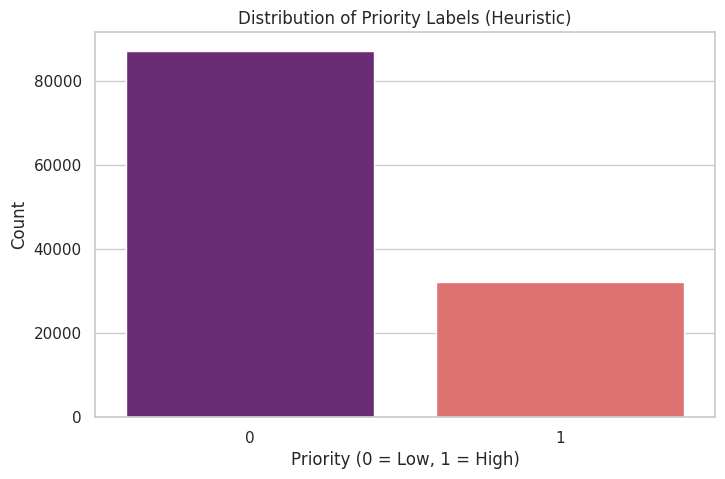

In [8]:
# Define high-priority keywords
# These cover: technical issues, financial/billing, and urgent sentiment
urgency_keywords = [
    'urgent', 'emergency', 'hacked', 'stolen', 'broken', 'not working', 
    'error', 'fraud', 'payment', 'refund', 'money', 'scam', 'cancel', 
    'help', 'stuck', 'fix', 'lost', 'issue', 'problem', 'worst', 'terrible'
]

def label_priority(text):
    """
    Returns 1 (High Priority) if any urgency keyword is in the text, else 0 (Low Priority).
    """
    if any(word in text for word in urgency_keywords):
        return 1
    return 0

# Create the label column
df_filtered['priority'] = df_filtered['clean_text'].apply(label_priority)

# Check the distribution of our new labels
priority_counts = df_filtered['priority'].value_counts()
priority_pct = df_filtered['priority'].value_counts(normalize=True) * 100

print("--- Priority Label Distribution ---")
print(f"Low Priority (0):  {priority_counts[0]} ({priority_pct[0]:.2f}%)")
print(f"High Priority (1): {priority_counts[1]} ({priority_pct[1]:.2f}%)")

# Visualize the imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df_filtered, x='priority', palette='magma')
plt.title('Distribution of Priority Labels (Heuristic)')
plt.xlabel('Priority (0 = Low, 1 = High)')
plt.ylabel('Count')

# Save the graph
plt.savefig(f"{GRAPHS_PATH}priority_distribution.png", bbox_inches='tight')
print(f"\nSaved distribution graph to {GRAPHS_PATH}priority_distribution.png")

# Verification: Show samples of High Priority tweets
print("\n--- High Priority Samples ---")
print(df_filtered[df_filtered['priority'] == 1][['clean_text']].sample(5))

## Step 6: Stratified Data Splitting (60/20/20)
**Source (PDF Section: DATASET):** "The dataset is... unbalanced."

To ensure our models are evaluated fairly, we need to split our data into three distinct sets:
1. **Train (60%):** Used to train the ML models.
2. **Validation (20%):** Used to compare the 4 models and tune hyperparameters.
3. **Test (20%):** The final "hold-out" set used to report the metrics you will defend in your README.

We use `stratify=y` to maintain the 73/27 priority distribution in every single split. This prevents the model from being evaluated on a "lucky" or "unlucky" distribution of urgent tickets.

--- Split Results ---
Train set:      71616 samples (60%)
Validation set: 23872 samples (20%)
Test set:       23873 samples (20%)

Files successfully saved to ../data/


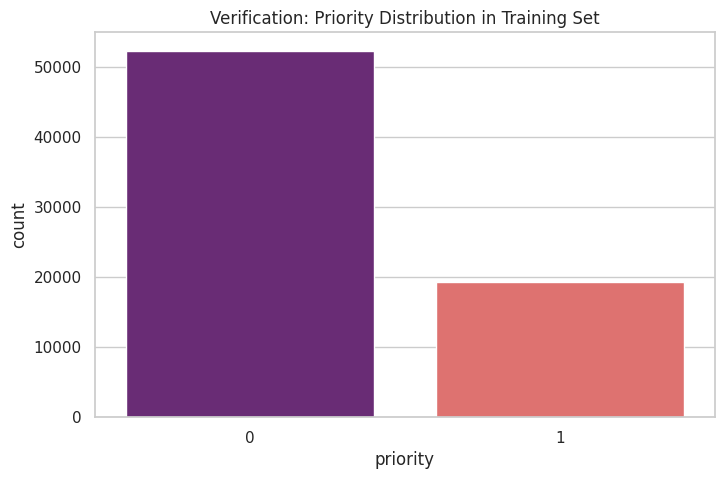

In [9]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_filtered[['clean_text', 'author_id']]
y = df_filtered['priority']

# 1. First split: Separate 20% for the final TEST set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Second split: Separate the remaining 80% into TRAIN (60%) and VAL (20%)
# Since 0.25 * 0.80 = 0.20, we use test_size=0.25 here
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print("--- Split Results ---")
print(f"Train set:      {len(X_train)} samples ({(len(X_train)/len(df_filtered))*100:.0f}%)")
print(f"Validation set: {len(X_val)} samples ({(len(X_val)/len(df_filtered))*100:.0f}%)")
print(f"Test set:       {len(X_test)} samples ({(len(X_test)/len(df_filtered))*100:.0f}%)")

# Combine X and y back together for saving
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Save to the data/ folder for Phase 2
train_df.to_csv(f"{PROCESSED_DATA_PATH}train.csv", index=False)
val_df.to_csv(f"{PROCESSED_DATA_PATH}val.csv", index=False)
test_df.to_csv(f"{PROCESSED_DATA_PATH}test.csv", index=False)

print(f"\nFiles successfully saved to {PROCESSED_DATA_PATH}")

# Fix the FutureWarning for your countplot in the next run
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='priority', hue='priority', palette='magma', legend=False)
plt.title('Verification: Priority Distribution in Training Set')
plt.show()